In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Barttorvik Away-Neutral.csv to Barttorvik Away-Neutral (3).csv
Saving Shooting Splits.csv to Shooting Splits (4).csv
Saving Tournament Matchups.csv to Tournament Matchups (4).csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_bart = pd.read_csv("Barttorvik Away-Neutral.csv")
df_shoot = pd.read_csv("Shooting Splits.csv")
df_matchups = pd.read_csv("Tournament Matchups.csv")

def clean_cols(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return df

df_bart = clean_cols(df_bart)
df_shoot = clean_cols(df_shoot)
df_matchups = clean_cols(df_matchups)

print("Bart:", df_bart.shape)
print("Shoot:", df_shoot.shape)
print("Matchups:", df_matchups.shape)

Bart: (1147, 85)
Shoot: (1017, 37)
Matchups: (2140, 8)


In [ ]:
bart_keep = [
    'year', 'team_no', 'team',
    'badj_o', 'badj_d',
    'efg%', 'efg%d',
    'ftr', 'ftrd',
    'tov%', 'tov%d',
    'oreb%', 'dreb%',
    'op_oreb%', 'op_dreb%',
    'raw_t',
    '2pt%', '2pt%d',
    '3pt%', '3pt%d',
    'blk%', 'blked%',
    'ast%', 'op_ast%',
    '2ptr', '3ptr',
    '2ptrd', '3ptrd',
    'badj_t',
    'avg_hgt', 'eff_hgt',
    'exp', 'talent',
    'ft%', 'op_ft%',
    'pppo', 'pppd'
]

bart_keep = [c for c in bart_keep if c in df_bart.columns]
df_bart = df_bart[bart_keep].copy()

print(df_bart.shape)
print(df_bart.columns.tolist())

(1147, 37)
['year', 'team_no', 'team', 'badj_o', 'badj_d', 'efg%', 'efg%d', 'ftr', 'ftrd', 'tov%', 'tov%d', 'oreb%', 'dreb%', 'op_oreb%', 'op_dreb%', 'raw_t', '2pt%', '2pt%d', '3pt%', '3pt%d', 'blk%', 'blked%', 'ast%', 'op_ast%', '2ptr', '3ptr', '2ptrd', '3ptrd', 'badj_t', 'avg_hgt', 'eff_hgt', 'exp', 'talent', 'ft%', 'op_ft%', 'pppo', 'pppd']


In [ ]:
shoot_keep = [
    'year', 'team_no', 'team',
    'dunks_fg%', 'dunks_share', 'dunks_fg%d', 'dunks_d_share',
    'close_twos_fg%', 'close_twos_share', 'close_twos_fg%d', 'close_twos_d_share',
    'farther_twos_fg%', 'farther_twos_share', 'farther_twos_fg%d', 'farther_twos_d_share',
    'threes_fg%', 'threes_share', 'threes_fg%d', 'threes_d_share'
]

shoot_keep = [c for c in shoot_keep if c in df_shoot.columns]
df_shoot = df_shoot[shoot_keep].copy()

print(df_shoot.shape)
print(df_shoot.columns.tolist())

(1017, 19)
['year', 'team_no', 'team', 'dunks_fg%', 'dunks_share', 'dunks_fg%d', 'dunks_d_share', 'close_twos_fg%', 'close_twos_share', 'close_twos_fg%d', 'close_twos_d_share', 'farther_twos_fg%', 'farther_twos_share', 'farther_twos_fg%d', 'farther_twos_d_share', 'threes_fg%', 'threes_share', 'threes_fg%d', 'threes_d_share']


In [ ]:
df_bart = df_bart.drop_duplicates(subset=['year', 'team_no']).copy()
df_shoot = df_shoot.drop_duplicates(subset=['year', 'team_no']).copy()

for df_name in ['df_bart', 'df_shoot']:
    temp = locals()[df_name]
    num_cols = temp.select_dtypes(include=['number']).columns
    temp[num_cols] = temp[num_cols].fillna(temp[num_cols].median())
    locals()[df_name] = temp

print(df_bart.shape, df_shoot.shape)

(1147, 37) (1017, 19)


In [ ]:
df = df_bart.merge(
    df_shoot.drop(columns=[c for c in ['team'] if c in df_shoot.columns]),
    on=['year', 'team_no'],
    how='left'
)

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df = df.drop_duplicates(subset=['year', 'team_no']).copy()

print(df.shape)
print(df[['year', 'team_no']].duplicated().sum())
df.head()

(1147, 53)
0


,year,team_no,team,badj_o,badj_d,efg%,efg%d,ftr,ftrd,tov%,...,close_twos_fg%d,close_twos_d_share,farther_twos_fg%,farther_twos_share,farther_twos_fg%d,farther_twos_d_share,threes_fg%,threes_share,threes_fg%d,threes_d_share
0,2025,1147,Akron,108.6,103.9,53.6,49.9,26.9,31.7,17.9,...,55.3,41.7,42.0,16.5,41.0,20.3,36.6,45.4,31.9,38.0
1,2025,1146,Alabama,130.5,99.5,57.0,50.7,37.4,38.9,17.1,...,56.8,34.5,50.0,11.8,39.6,30.4,35.0,46.2,30.8,35.1
2,2025,1145,Alabama St.,100.5,107.7,45.6,50.5,28.4,37.4,14.2,...,57.7,39.0,31.5,20.5,37.4,21.6,32.9,42.9,33.4,39.5
3,2025,1144,American,102.0,110.7,50.2,55.1,27.5,39.0,16.9,...,62.2,40.2,39.4,21.4,37.9,24.2,35.1,44.8,33.6,35.7
4,2025,1143,Arizona,120.7,96.3,50.1,49.4,33.9,32.5,17.0,...,55.8,29.5,38.4,25.6,38.5,28.6,32.4,34.6,33.6,41.9


In [ ]:
seed_perf = df_games.groupby('seed1')['team1_win'].mean().reset_index()

seed_perf.columns = ['seed', 'win_rate']
seed_perf = seed_perf.sort_values('seed')

print(seed_perf)

NameError: name 'df_games' is not defined

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(seed_perf['seed'], seed_perf['win_rate'], marker='o')
plt.title("Win Rate by Seed")
plt.xlabel("Seed")
plt.ylabel("Win Rate")
plt.grid()
plt.show()

NameError: name 'seed_perf' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
df_games['upset'] = (
    ((df_games['seed1'] > df_games['seed2']) & (df_games['team1_win'] == 1)) |
    ((df_games['seed2'] > df_games['seed1']) & (df_games['team1_win'] == 0))
).astype(int)

upset_rate = df_games['upset'].mean()
print("Overall Upset Rate:", upset_rate)

Overall Upset Rate: 0.28317757009345795


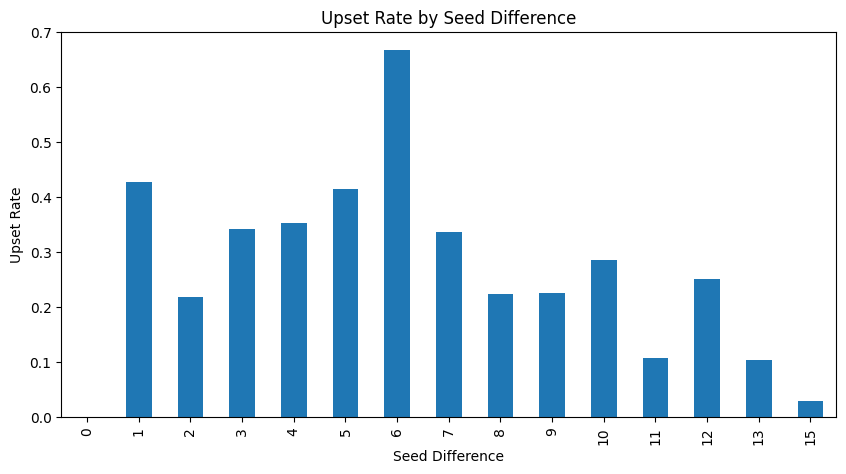

In [ ]:
df_games['seed_diff'] = abs(df_games['seed1'] - df_games['seed2'])

upset_by_diff = df_games.groupby('seed_diff')['upset'].mean()

plt.figure(figsize=(10,5))
upset_by_diff.plot(kind='bar')
plt.title("Upset Rate by Seed Difference")
plt.xlabel("Seed Difference")
plt.ylabel("Upset Rate")
plt.show()

In [ ]:
print(df_matchups.columns.tolist())
print(df_matchups.shape)
df_matchups.head()

['year', 'by_year_no', 'team_no', 'team', 'seed', 'round', 'current_round', 'score', 'game_id']
(2140, 9)


,year,by_year_no,team_no,team,seed,round,current_round,score,game_id
0,2008,126,31,North Carolina,1,4,64,113,0
1,2008,125,32,Mount St. Mary's,16,64,64,74,0
2,2008,124,44,Indiana,8,64,64,72,1
3,2008,123,63,Arkansas,9,32,64,86,1
4,2008,122,30,Notre Dame,5,32,64,68,2


In [ ]:
df_games['seed_diff'] = abs(df_games['seed1'] - df_games['seed2'])

seed_diff_counts = df_games['seed_diff'].value_counts().sort_index()

print(seed_diff_counts)

seed_diff
0      16
1     173
2      23
3     143
4      51
5     111
6       9
7     113
8     125
9      84
10      7
11     75
12      4
13     68
15     68
Name: count, dtype: int64


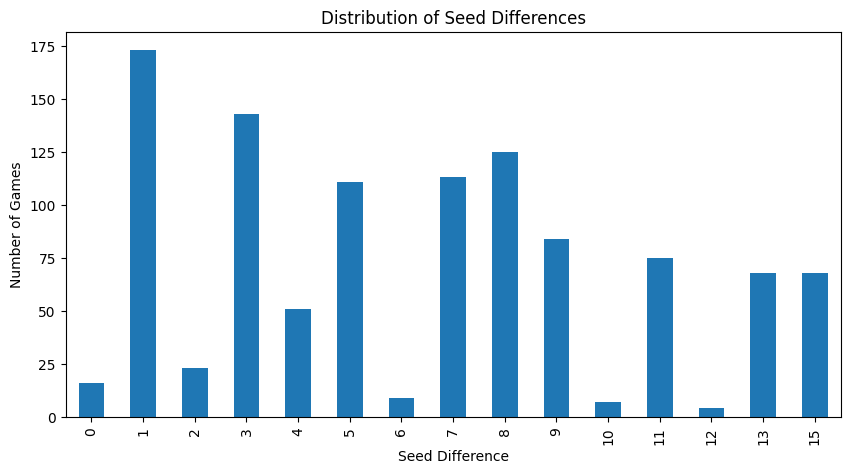

In [ ]:
plt.figure(figsize=(10,5))
seed_diff_counts.plot(kind='bar')
plt.title("Distribution of Seed Differences")
plt.xlabel("Seed Difference")
plt.ylabel("Number of Games")
plt.show()

In [ ]:
win_rate_diff = df_games.groupby('seed_diff')['team1_win'].mean()

print(win_rate_diff)

seed_diff
0     0.437500
1     0.508671
2     0.565217
3     0.559441
4     0.549020
5     0.477477
6     0.333333
7     0.646018
8     0.504000
9     0.714286
10    0.428571
11    0.893333
12    0.750000
13    0.897059
15    0.970588
Name: team1_win, dtype: float64


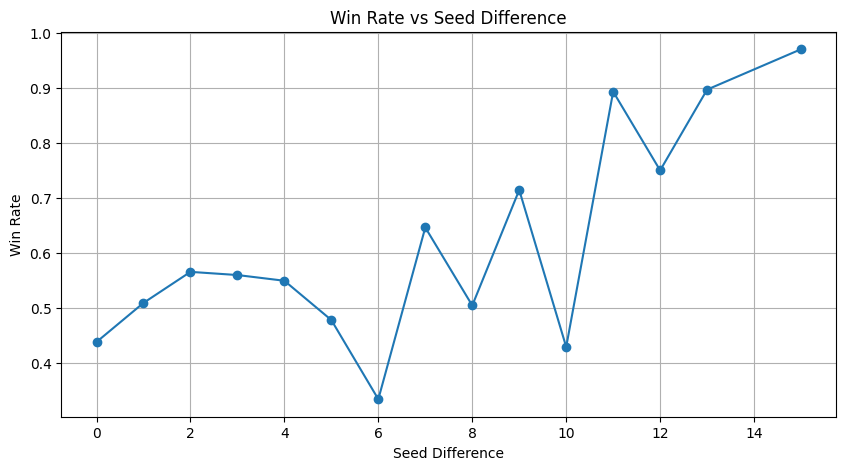

In [ ]:
plt.figure(figsize=(10,5))
win_rate_diff.plot(marker='o')
plt.title("Win Rate vs Seed Difference")
plt.xlabel("Seed Difference")
plt.ylabel("Win Rate")
plt.grid()
plt.show()

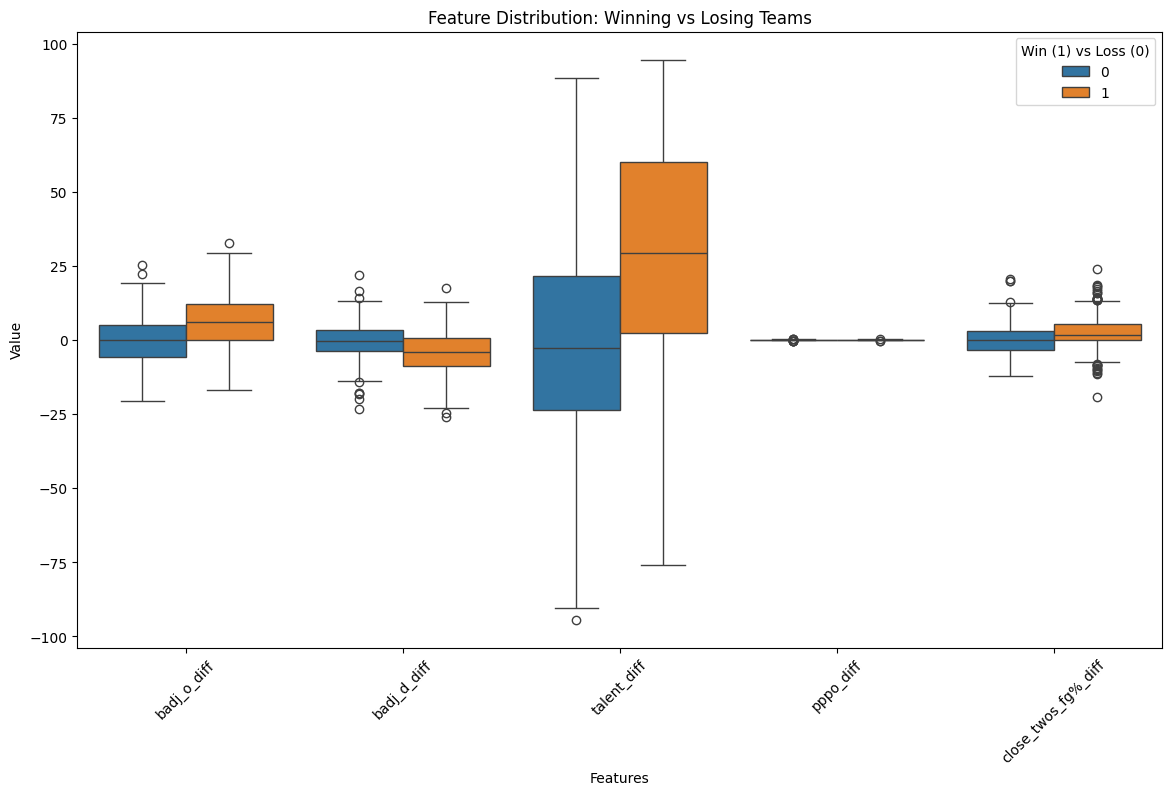

In [ ]:
plt.figure(figsize=(14,8))

features = [
    'badj_o_diff',
    'badj_d_diff',
    'talent_diff',
    'pppo_diff',
    'close_twos_fg%_diff'
]

# reshape data for seaborn
plot_data = df_model[features + ['team1_win']].melt(
    id_vars='team1_win',
    var_name='Feature',
    value_name='Value'
)

sns.boxplot(
    x='Feature',
    y='Value',
    hue='team1_win',
    data=plot_data
)

plt.title("Feature Distribution: Winning vs Losing Teams")
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Value")
plt.legend(title="Win (1) vs Loss (0)")

plt.show()

In [ ]:
df_matchups = df_matchups.sort_values(['year', 'by_year_no'], ascending=[True, False]).reset_index(drop=True)
df_matchups['game_id'] = df_matchups.groupby('year').cumcount() // 2

df_games = df_matchups.groupby(['year', 'game_id']).nth([0, 1]).reset_index()

team1 = df_games[df_games.groupby(['year', 'game_id']).cumcount() == 0].copy()
team2 = df_games[df_games.groupby(['year', 'game_id']).cumcount() == 1].copy()

team1 = team1.rename(columns={
    'team_no': 'team1_no',
    'team': 'team1',
    'seed': 'seed1',
    'round': 'round1',
    'current_round': 'current_round1',
    'score': 'score1'
})

team2 = team2.rename(columns={
    'team_no': 'team2_no',
    'team': 'team2',
    'seed': 'seed2',
    'round': 'round2',
    'current_round': 'current_round2',
    'score': 'score2'
})

team1 = team1[['year', 'game_id', 'team1_no', 'team1', 'seed1', 'round1', 'current_round1', 'score1']]
team2 = team2[['year', 'game_id', 'team2_no', 'team2', 'seed2', 'round2', 'current_round2', 'score2']]

df_games = team1.merge(team2, on=['year', 'game_id'], how='inner')

df_games['team1_win'] = (df_games['score1'] > df_games['score2']).astype(int)

print(df_games.shape)
df_games.head()

(1070, 15)


,year,game_id,team1_no,team1,seed1,round1,current_round1,score1,team2_no,team2,seed2,round2,current_round2,score2,team1_win
0,2008,0,31,North Carolina,1,4,64,113,32,Mount St. Mary's,16,64,64,74,1
1,2008,1,44,Indiana,8,64,64,72,63,Arkansas,9,32,64,86,0
2,2008,2,30,Notre Dame,5,32,64,68,48,George Mason,12,64,64,50,1
3,2008,3,6,Washington St.,4,16,64,71,3,Winthrop,13,64,64,40,1
4,2008,4,29,Oklahoma,6,32,64,72,23,Saint Joseph's,11,64,64,64,1


In [ ]:
df_model = df_games.merge(
    df,
    left_on=['year', 'team1_no'],
    right_on=['year', 'team_no'],
    how='left'
)

team1_feature_cols = {col: f"{col}_1" for col in df.columns if col != 'year'}
df_model = df_model.rename(columns=team1_feature_cols)

df_model = df_model.merge(
    df,
    left_on=['year', 'team2_no'],
    right_on=['year', 'team_no'],
    how='left',
    suffixes=('', '_2')
)

team2_feature_cols = {col: f"{col}_2" for col in df.columns if col != 'year'}
df_model = df_model.rename(columns=team2_feature_cols)

print(df_model.shape)
print(df_model[['year', 'game_id']].duplicated().sum())

(1070, 119)
0


In [ ]:
feature_cols = [c for c in df.columns if c not in ['year', 'team_no', 'team']]

diff_data = {}
for col in feature_cols:
    col1 = f'{col}_1'
    col2 = f'{col}_2'
    if col1 in df_model.columns and col2 in df_model.columns:
        diff_data[f'{col}_diff'] = df_model[col1] - df_model[col2]

diff_df = pd.DataFrame(diff_data, index=df_model.index)
df_model = pd.concat([df_model, diff_df], axis=1)

print(df_model.shape)

(1070, 169)


In [ ]:
test_year = df_model['year'].max()

df_train = df_model[df_model['year'] < test_year].copy()
df_test = df_model[df_model['year'] == test_year].copy()

print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Test year:", test_year)

Train: (1007, 169)
Test: (63, 169)
Test year: 2025


In [ ]:
target = 'team1_win'

def build_X_y(df_input):
    numeric_df = df_input.select_dtypes(include=['int64', 'float64']).copy()

    drop_cols = [
        'game_id',
        'team1_no', 'team2_no',
        'score1', 'score2',
        'seed1', 'seed2',
        'round1', 'round2',
        'current_round1', 'current_round2',
        'team1_win'
    ]

    X = numeric_df.drop(columns=[c for c in drop_cols if c in numeric_df.columns], errors='ignore')
    y = df_input[target].copy()
    return X, y

X_train, y_train = build_X_y(df_train)
X_test, y_test = build_X_y(df_test)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1007, 153) (1007,)
(63, 153) (63,)


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=10000)
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.54      0.75      0.62        20
           1       0.86      0.70      0.77        43

    accuracy                           0.71        63
   macro avg       0.70      0.72      0.70        63
weighted avg       0.76      0.71      0.72        63



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7619047619047619
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        20
           1       0.79      0.88      0.84        43

    accuracy                           0.76        63
   macro avg       0.73      0.69      0.70        63
weighted avg       0.75      0.76      0.75        63



In [ ]:
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = feature_importance.sort_values(ascending=False).head(15)

print(top_features)

badj_o_diff            0.051352
talent_diff            0.048806
talent_2               0.032682
badj_d_diff            0.031488
badj_o_2               0.028916
badj_d_2               0.027542
close_twos_fg%_diff    0.019713
talent_1               0.017261
pppo_diff              0.016064
badj_o_1               0.014636
threes_fg%d_2          0.012920
avg_hgt_2              0.010613
dunks_share_diff       0.010358
avg_hgt_diff           0.009750
pppo_1                 0.009515
dtype: float64


In [ ]:
df_games['upset'] = (
    ((df_games['seed1'] > df_games['seed2']) & (df_games['team1_win'] == 1)) |
    ((df_games['seed2'] > df_games['seed1']) & (df_games['team1_win'] == 0))
).astype(int)

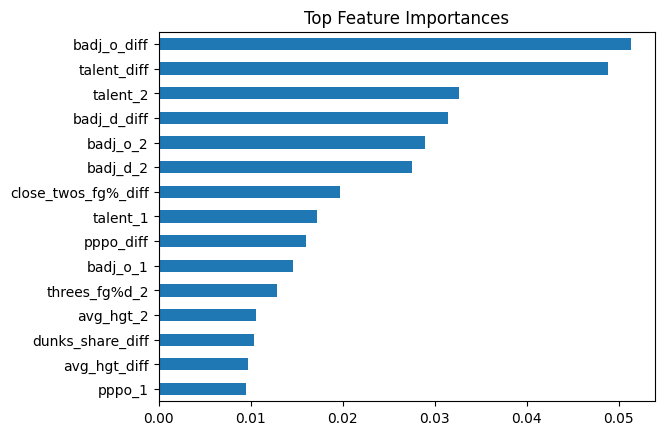

In [ ]:
top_features.plot(kind='barh')
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()

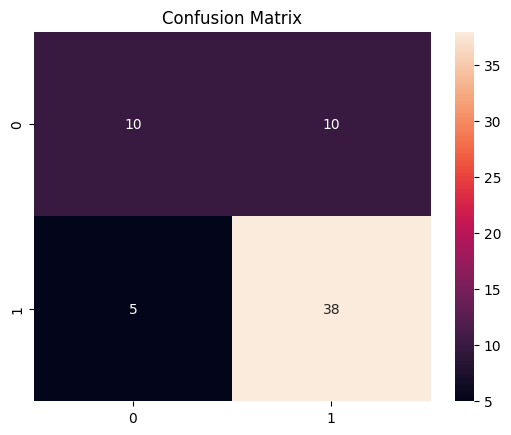

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
latest_year = df_model['year'].max()

df_2025 = df_model[df_model['year'] == latest_year].copy()

print(df_2025.shape)

(63, 169)


In [ ]:
X_2025, _ = build_X_y(df_2025)

In [ ]:
# Get average strength score for each team
team_scores = df_2025.groupby('team1').mean(numeric_only=True)

# keep only model features
team_scores = team_scores[X_train.columns]

# predict probability (proxy strength)
team_scores['win_prob'] = model.predict_proba(team_scores)[:,1]

team_scores = team_scores.sort_values('win_prob', ascending=False)

team_scores.head(10)

,year,team_no_1,badj_o_1,badj_d_1,efg%_1,efg%d_1,ftr_1,ftrd_1,tov%_1,tov%d_1,...,close_twos_d_share_diff,farther_twos_fg%_diff,farther_twos_share_diff,farther_twos_fg%d_diff,farther_twos_d_share_diff,threes_fg%_diff,threes_share_diff,threes_fg%d_diff,threes_d_share_diff,win_prob
team1,,,,,,,,,,,,,,,,,,,,,
Tennessee,2025.0,1094.0,118.5,90.1,50.7,44.9,38.1,30.1,17.8,16.6,...,-3.5,-2.5,4.8,0.9,4.3,-0.5,-4.7,-6.7,-0.7,0.983306
St. John's,2025.0,1095.0,113.4,85.7,49.3,46.3,24.3,31.4,15.3,23.0,...,3.5,1.4,5.2,-12.0,0.2,-6.3,-8.3,-3.3,-3.7,0.974139
Michigan St.,2025.0,1113.0,116.2,91.8,49.7,46.3,36.9,33.4,16.7,14.8,...,-9.7,1.3,4.5,0.8,4.4,-2.6,-2.1,-4.3,5.4,0.959284
Arizona,2025.0,1143.0,120.7,96.3,50.1,49.4,33.9,32.5,17.0,15.6,...,-12.2,-3.6,9.1,-2.5,8.3,-4.2,-10.8,1.7,3.9,0.946000
Alabama,2025.0,1146.0,130.5,99.5,57.0,50.7,37.4,38.9,17.1,13.1,...,-7.2,14.9,-8.4,-1.7,7.8,0.1,9.4,-3.4,-0.5,0.943716
Texas A&M,2025.0,1092.0,112.5,92.8,46.1,51.0,38.0,33.9,19.0,18.8,...,-1.1,-13.7,-2.3,-1.7,2.2,-7.4,5.6,-0.3,-1.0,0.906666
Purdue,2025.0,1101.0,118.5,100.5,52.0,53.6,34.4,33.3,17.2,16.3,...,-5.6,-1.0,12.4,-0.9,-1.2,1.9,-0.9,-2.2,6.7,0.905091
Iowa St.,2025.0,1124.0,119.4,96.0,52.7,52.2,34.4,30.0,16.9,19.3,...,-1.9,-3.2,7.7,-7.3,-1.6,-0.9,-10.5,2.2,3.5,0.884744
Maryland,2025.0,1117.0,121.1,95.0,51.3,50.7,29.2,24.6,14.1,18.8,...,-6.8,-4.2,9.5,0.8,5.3,5.6,1.9,-1.4,1.4,0.875959


In [ ]:
# Seed success using win rate
seed_perf = df_games.groupby('seed1')['team1_win'].mean().reset_index()
seed_perf.columns = ['seed', 'win_rate']

# baseline win rate
baseline = df_games['team1_win'].mean()

# success score relative to baseline
seed_perf['success_score'] = seed_perf['win_rate'] - baseline

print(seed_perf.sort_values('seed'))

    seed  win_rate  success_score
0      1  0.811024       0.186725
1      2  0.820513       0.196214
2      3  0.716814       0.092515
3      4  0.740741       0.116442
4      5  0.558333      -0.065966
5      6  0.452174      -0.172125
6      7  0.477477      -0.146822
7      8  0.518987      -0.105312
8      9  0.666667       0.042368
9     10  0.296296      -0.328003
10    11  0.423077      -0.201222
11    12  0.275862      -0.348437
12    16  0.000000      -0.624299


In [ ]:
# 1) Expected win rate by seed
seed_expectation = df_games.groupby('seed1')['team1_win'].mean().reset_index()
seed_expectation.columns = ['seed', 'expected_win_rate']

# 2) Team performance from both team1 and team2 sides, keeping seed
team1_perf = df_games[['team1', 'seed1', 'team1_win']].rename(
    columns={'team1': 'team', 'seed1': 'seed', 'team1_win': 'win'}
)

team2_perf = df_games[['team2', 'seed2', 'team1_win']].rename(
    columns={'team2': 'team', 'seed2': 'seed'}
)
team2_perf['win'] = 1 - team2_perf['team1_win']
team2_perf = team2_perf.drop(columns=['team1_win'])

team_all = pd.concat([team1_perf, team2_perf], ignore_index=True)

# 3) Aggregate actual team win rate
team_perf = team_all.groupby(['team', 'seed']).agg(
    games=('win', 'count'),
    wins=('win', 'sum')
).reset_index()

team_perf['actual_win_rate'] = team_perf['wins'] / team_perf['games']

# 4) Compare against seed expectation
team_perf = team_perf.merge(seed_expectation, on='seed', how='left')
team_perf['overperformance_score'] = team_perf['actual_win_rate'] - team_perf['expected_win_rate']

# 5) Filter small samples
team_perf_filtered = team_perf[team_perf['games'] >= 5].copy()

top_overperformers = team_perf_filtered.sort_values(
    'overperformance_score', ascending=False
).head(10)

top_underperformers = team_perf_filtered.sort_values(
    'overperformance_score', ascending=True
).head(10)

print("Top Overperformers:")
print(top_overperformers[['team', 'seed', 'games', 'actual_win_rate', 'expected_win_rate', 'overperformance_score']])

print("\nTop Underperformers:")
print(top_underperformers[['team', 'seed', 'games', 'actual_win_rate', 'expected_win_rate', 'overperformance_score']])

Top Overperformers:
                 team  seed  games  actual_win_rate  expected_win_rate  \
591          Syracuse    10      5         0.800000           0.296296   
493            Oregon    12      6         0.666667           0.275862   
123       Connecticut     7      7         0.857143           0.477477   
313    Loyola Chicago    11      5         0.800000           0.423077   
646              UCLA    11      8         0.750000           0.423077   
528          Richmond    12      5         0.600000           0.275862   
724  Western Kentucky    12      5         0.600000           0.275862   
566    South Carolina     7      5         0.800000           0.477477   
281          Kentucky     8      6         0.833333           0.518987   
77             Butler     8      6         0.833333           0.518987   

     overperformance_score  
591               0.503704  
493               0.390805  
123               0.379665  
313               0.376923  
646               0.

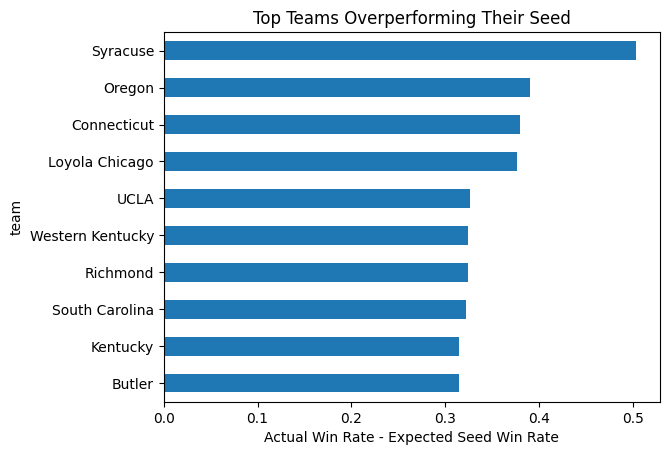

In [ ]:
top_overperformers.set_index('team')['overperformance_score'].sort_values().plot(
    kind='barh', title='Top Teams Overperforming Their Seed'
)
plt.xlabel('Actual Win Rate - Expected Seed Win Rate')
plt.show()

In [ ]:
latest_year = df_model['year'].max()

# get unique teams
teams_latest = df[['year','team_no','team']].drop_duplicates()
teams_latest = teams_latest[teams_latest['year'] == latest_year]

team_strength = []

for _, row in teams_latest.iterrows():
    team_id = row['team_no']
    team_name = row['team']

    # get matchups where team is team1
    team_rows = df_model[
        (df_model['year'] == latest_year) &
        (df_model['team1_no'] == team_id)
    ]

    if len(team_rows) > 0:
        X_temp, _ = build_X_y(team_rows)
        probs = model.predict_proba(X_temp)[:,1]
        avg_prob = probs.mean()

        team_strength.append((team_name, avg_prob))

# create ranking
team_scores = pd.DataFrame(team_strength, columns=['team','win_prob'])
team_scores = team_scores.sort_values('win_prob', ascending=False)

# final outputs
final_four = team_scores.head(4)['team'].tolist()
winner = team_scores.head(1)['team'].iloc[0]

print("Final Four:", final_four)
print("Predicted Winner:", winner)

Final Four: ['Tennessee', "St. John's", 'Michigan St.', 'Arizona']
Predicted Winner: Tennessee
